In [2]:
import os
print(os.listdir("/kaggle/input/datasets/bratjay/"))
print(os.listdir("/kaggle/input/datasets/aryashah2k/"))

['ua-detrac-orig']
['ucsd-pedestrian-database']


In [3]:
import os

ucsd_path = "/kaggle/input/datasets/aryashah2k/ucsd-pedestrian-database/ucsdpeds"

for root, dirs, files in os.walk(ucsd_path):
    print("ROOT:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    break

ROOT: /kaggle/input/datasets/aryashah2k/ucsd-pedestrian-database/ucsdpeds
DIRS: ['vidf']
FILES: ['README.pdf']


In [4]:
vidf_path = "/kaggle/input/datasets/aryashah2k/ucsd-pedestrian-database/ucsdpeds/vidf"

import os

for root, dirs, files in os.walk(vidf_path):
    print("ROOT:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    break

ROOT: /kaggle/input/datasets/aryashah2k/ucsd-pedestrian-database/ucsdpeds/vidf
DIRS: ['vidf5_33_002.y', 'vidf4_33_005.y', 'vidf2_33_006.y', 'vidf1_33_024.y', 'vidf2_33_012.y']
FILES: []


In [5]:
for root, dirs, files in os.walk(vidf_path):
    if len(files) > 0:
        print("ROOT:", root)
        print("FILES:", files[:5])
        break

ROOT: /kaggle/input/datasets/aryashah2k/ucsd-pedestrian-database/ucsdpeds/vidf/vidf5_33_002.y
FILES: ['vidf5_33_002_f089.png', 'vidf5_33_002_f035.png', 'vidf5_33_002_f062.png', 'vidf5_33_002_f183.png', 'vidf5_33_002_f135.png']


In [6]:
import os
import cv2
import numpy as np

def load_ucsd_frames(base_path, img_size=(64, 64)):
    frames = []
    
    for root, dirs, files in os.walk(base_path):
        for file in sorted(files):
            if file.endswith(".png"):
                img_path = os.path.join(root, file)
                
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, img_size)
                img = img / 255.0
                
                frames.append(img)
    
    return np.array(frames)

ucsd_path = "/kaggle/input/datasets/aryashah2k/ucsd-pedestrian-database/ucsdpeds/vidf"

ucsd_frames = load_ucsd_frames(ucsd_path)

print("Shape:", ucsd_frames.shape)

Shape: (32597, 64, 64)


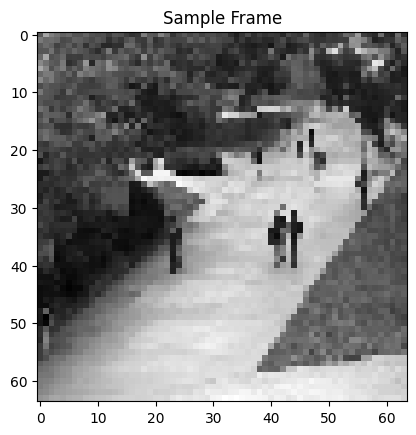

In [7]:
import matplotlib.pyplot as plt

plt.imshow(ucsd_frames[0], cmap='gray')
plt.title("Sample Frame")
plt.show()



ucsd_frames → (N, 64, 64)

But LSTM needs:

(Batch, Time, Features)

So we convert frames into sliding window sequences.

Example:

Frames:

f1, f2, f3, f4, f5, f6...

With seq_len = 5, we create:

[f1 f2 f3 f4 f5]
[f2 f3 f4 f5 f6]
[f3 f4 f5 f6 f7]
...

Each sequence = one training sample


In [8]:
def create_sequences(data, seq_len=10):
    sequences = []
    
    for i in range(len(data) - seq_len):
        sequences.append(data[i:i+seq_len])
    
    return np.array(sequences)

ucsd_sequences = create_sequences(ucsd_frames, seq_len=10)

print("Shape:", ucsd_sequences.shape)

Shape: (32587, 10, 64, 64)


In [9]:
ucsd_sequences = np.expand_dims(ucsd_sequences, axis=2)

print("Final Shape:", ucsd_sequences.shape)

Final Shape: (32587, 10, 1, 64, 64)


This model will:

CNN → understand each frame (spatial features)
LSTM → understand sequence (time patterns)
Autoencoder → reconstruct → detect anomalies
🧠 Model Idea (Simple View)
Input (sequence of frames)
        ↓
CNN (per frame)
        ↓
LSTM (sequence learning)
        ↓
Decoder (reconstruct frames)
        ↓
Compare input vs output → anomaly score

In [10]:
import torch
import torch.nn as nn

In [11]:
class CNN_LSTM_AE(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Smaller CNN Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),   # 64 → 32
            nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),  # 32 → 16
            nn.ReLU(),
            nn.Conv2d(16, 16, 3, stride=2, padding=1), # 16 → 8
            nn.ReLU()
        )
        
        # Smaller LSTM
        self.lstm = nn.LSTM(16*8*8, 64, batch_first=True)
        self.decoder_lstm = nn.LSTM(64, 16*8*8, batch_first=True)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(16, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        
        x = x.reshape(B*T, C, H, W)
        x = self.encoder(x)
        
        x = x.reshape(B, T, -1)  # 1024 features
        x, _ = self.lstm(x)
        
        x, _ = self.decoder_lstm(x)
        
        x = x.reshape(B*T, 16, 8, 8)
        x = self.decoder(x)
        
        x = x.reshape(B, T, 1, 64, 64)
        
        return x

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_LSTM_AE().to(device)
print(model)

CNN_LSTM_AE(
  (encoder): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (lstm): LSTM(1024, 64, batch_first=True)
  (decoder_lstm): LSTM(64, 1024, batch_first=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(8, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)


In [13]:
data = torch.tensor(ucsd_sequences).float().to(device)
print(data.shape)

torch.Size([32587, 10, 1, 64, 64])


In [14]:
subset_size = 3000
train_data = data[:subset_size]

print(train_data.shape)

torch.Size([3000, 10, 1, 64, 64])


In [15]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [16]:
from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(data[:5000])  # keep subset
loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [18]:
epochs = 7

for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for batch in loader:
        batch = batch[0].to(device)
        
        output = model(batch)
        loss = criterion(output, batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 3.1303
Epoch 2, Loss: 3.1055
Epoch 3, Loss: 3.0885
Epoch 4, Loss: 3.0749
Epoch 5, Loss: 3.0672
Epoch 6, Loss: 3.0553
Epoch 7, Loss: 3.0485


In [19]:
import os

detrac_base = "/kaggle/input/datasets/bratjay/ua-detrac-orig"

for root, dirs, files in os.walk(detrac_base):
    print("ROOT:", root)
    print("DIRS:", dirs[:5])
    print("FILES:", files[:5])
    break

ROOT: /kaggle/input/datasets/bratjay/ua-detrac-orig
DIRS: ['DETRAC-Test-Annotations-XML', 'DETRAC-MOT-toolkit', 'DETRAC-Images', 'DETRAC-Train-Annotations-XML']
FILES: []


In [20]:
detrac_img_path = "/kaggle/input/datasets/bratjay/ua-detrac-orig/DETRAC-Images"

In [21]:
import os

for root, dirs, files in os.walk(detrac_img_path):
    if len(files) > 0:
        print("ROOT:", root)
        print("FILES:", files[:5])
        break

ROOT: /kaggle/input/datasets/bratjay/ua-detrac-orig/DETRAC-Images/DETRAC-Images/MVI_39501
FILES: ['img00485.jpg', 'img00180.jpg', 'img00191.jpg', 'img00210.jpg', 'img00372.jpg']


In [22]:
import cv2
import numpy as np
import os

def load_detrac_frames(path, img_size=(64,64), max_frames=5000):
    frames = []
    
    for root, _, files in os.walk(path):
        for file in sorted(files):
            if file.endswith(".jpg"):
                img_path = os.path.join(root, file)
                
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                img = cv2.resize(img, img_size)
                img = img / 255.0
                
                frames.append(img)
                
                if len(frames) >= max_frames:
                    return np.array(frames)
    
    return np.array(frames)

detrac_frames = load_detrac_frames(detrac_img_path)

print("Shape:", detrac_frames.shape)

Shape: (5000, 64, 64)


In [23]:
detrac_sequences = create_sequences(detrac_frames, seq_len=10)
detrac_sequences = np.expand_dims(detrac_sequences, axis=2)

print(detrac_sequences.shape)

(4990, 10, 1, 64, 64)


In [24]:
model.eval()

CNN_LSTM_AE(
  (encoder): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (lstm): LSTM(1024, 64, batch_first=True)
  (decoder_lstm): LSTM(64, 1024, batch_first=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(8, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)

In [34]:
from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(torch.tensor(detrac_sequences[:2000], dtype=torch.float32))
loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [36]:
for epoch in range(7):
    model.train()
    total_loss = 0
    
    for batch in loader:
        batch = batch[0].to(device)
        
        output = model(batch)
        loss = criterion(output, batch)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Fine-tune Epoch {epoch+1}, Loss: {total_loss:.4f}")

Fine-tune Epoch 1, Loss: 8.8274
Fine-tune Epoch 2, Loss: 8.8009
Fine-tune Epoch 3, Loss: 8.7864
Fine-tune Epoch 4, Loss: 8.7844
Fine-tune Epoch 5, Loss: 8.7632
Fine-tune Epoch 6, Loss: 8.7587
Fine-tune Epoch 7, Loss: 8.7516


In [37]:
errors = []

with torch.no_grad():
    for i in range(0, len(detrac_sequences), 32):
        batch = detrac_sequences[i:i+32]
        batch = torch.tensor(batch, dtype=torch.float32).to(device)
        
        output = model(batch)
        
        # MSE per sequence
        loss = ((output - batch) ** 2).mean(dim=(1,2,3,4))
        errors.extend(loss.cpu().numpy())

errors = np.array(errors)

In [38]:
print("Min:", errors.min())
print("Max:", errors.max())
print("Mean:", errors.mean())
print("Std:", errors.std())

Min: 0.017112913
Max: 0.06737315
Mean: 0.029271593
Std: 0.011297542


In [40]:
threshold = errors.mean() + 3 * errors.std()
anomalies = np.where(errors > threshold)[0]

print("New Threshold:", threshold)
print("New Anomalies:", len(anomalies))

New Threshold: 0.06316422
New Anomalies: 76


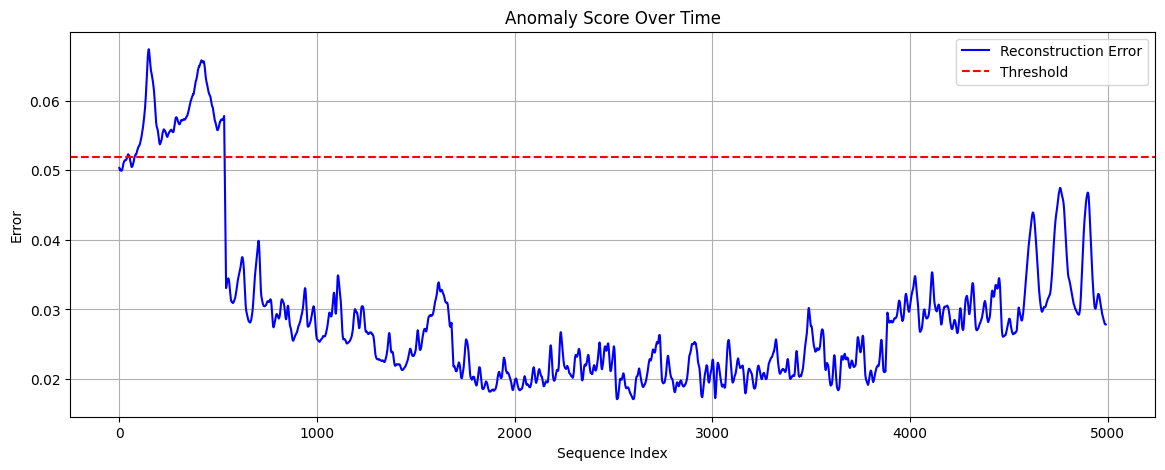

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(errors, color='blue', label='Reconstruction Error')

threshold = errors.mean() + 2*errors.std()
plt.axhline(y=threshold, color='red', linestyle='--', label='Threshold')

plt.title("Anomaly Score Over Time")
plt.xlabel("Sequence Index")
plt.ylabel("Error")
plt.legend()
plt.grid()
plt.show()

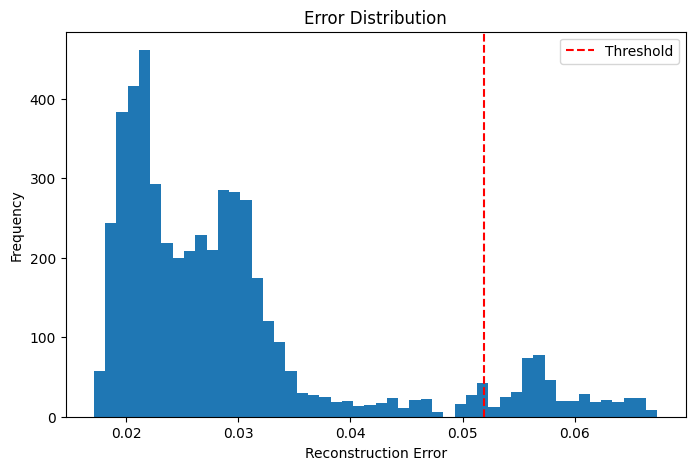

In [42]:
plt.figure(figsize=(8,5))
plt.hist(errors, bins=50)

plt.axvline(threshold, color='red', linestyle='--', label='Threshold')

plt.title("Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.legend()
plt.show()

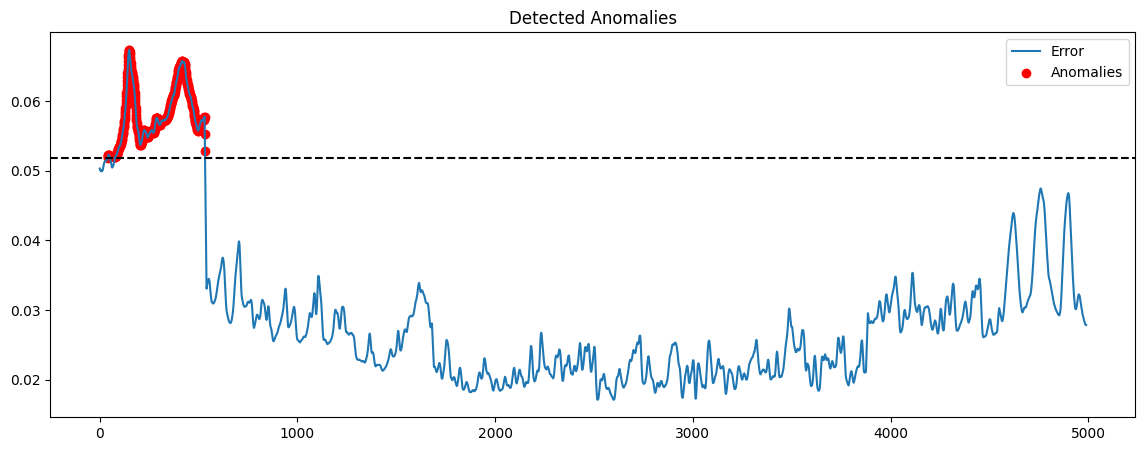

In [43]:
plt.figure(figsize=(14,5))
plt.plot(errors, label='Error')

anomalies = np.where(errors > threshold)[0]
plt.scatter(anomalies, errors[anomalies], color='red', label='Anomalies')

plt.axhline(y=threshold, color='black', linestyle='--')

plt.title("Detected Anomalies")
plt.legend()
plt.show()

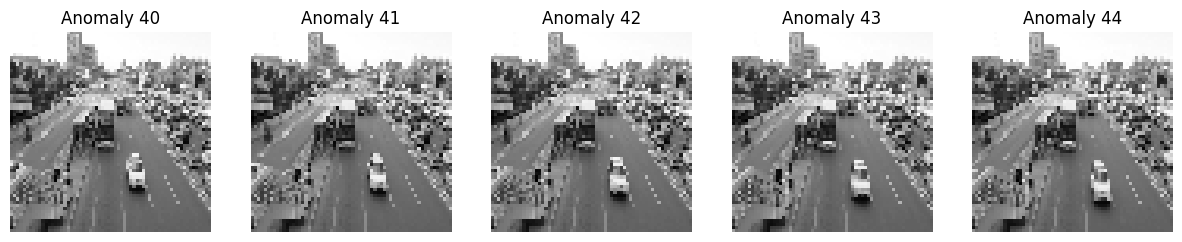

In [44]:
import matplotlib.pyplot as plt

def show_anomalies(sequences, anomalies, num=5):
    plt.figure(figsize=(15,3))
    
    for i, idx in enumerate(anomalies[:num]):
        frame = sequences[idx][0][0]  # first frame
        
        plt.subplot(1, num, i+1)
        plt.imshow(frame, cmap='gray')
        plt.title(f"Anomaly {idx}")
        plt.axis('off')
    
    plt.show()

show_anomalies(detrac_sequences, anomalies)

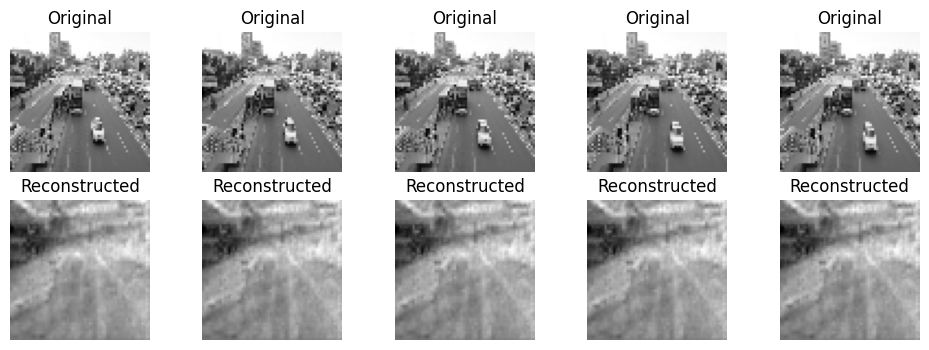

In [45]:
def compare_reconstruction(model, sequences, index):
    model.eval()
    
    sample = torch.tensor(sequences[index:index+1], dtype=torch.float32).to(device)
    
    with torch.no_grad():
        recon = model(sample).cpu().numpy()
    
    original = sequences[index]
    reconstructed = recon[0]
    
    plt.figure(figsize=(12,4))
    
    for i in range(5):
        plt.subplot(2,5,i+1)
        plt.imshow(original[i][0], cmap='gray')
        plt.title("Original")
        plt.axis('off')
        
        plt.subplot(2,5,i+6)
        plt.imshow(reconstructed[i][0], cmap='gray')
        plt.title("Reconstructed")
        plt.axis('off')
    
    plt.show()

# Try on anomaly
compare_reconstruction(model, detrac_sequences, anomalies[0])

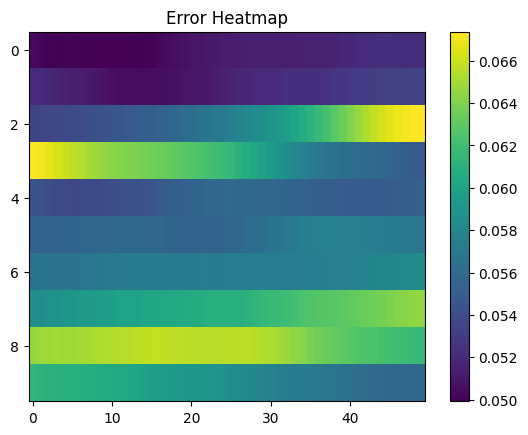

In [47]:
window = 50
heat = errors[:window*10].reshape(10, window)

plt.imshow(heat, aspect='auto')
plt.colorbar()
plt.title("Error Heatmap")
plt.show()

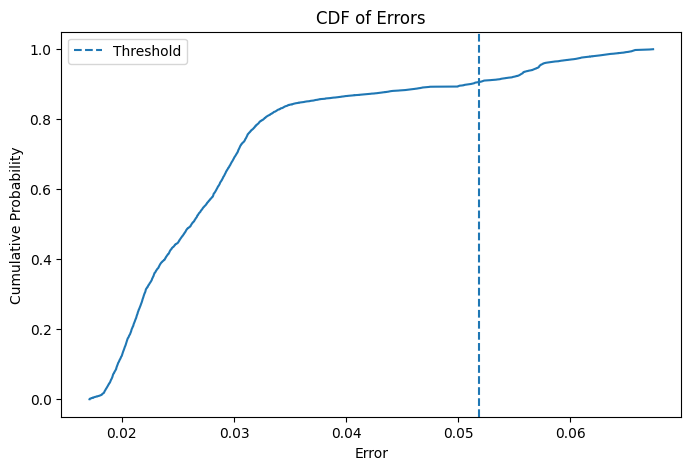

In [48]:
sorted_errors = np.sort(errors)
cdf = np.arange(len(errors)) / len(errors)

plt.figure(figsize=(8,5))
plt.plot(sorted_errors, cdf)

plt.axvline(errors.mean() + 2*errors.std(), linestyle='--', label='Threshold')

plt.title("CDF of Errors")
plt.xlabel("Error")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.show()

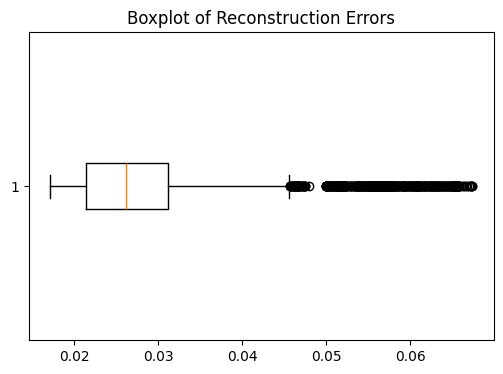

In [49]:
plt.figure(figsize=(6,4))
plt.boxplot(errors, vert=False)
plt.title("Boxplot of Reconstruction Errors")
plt.show()

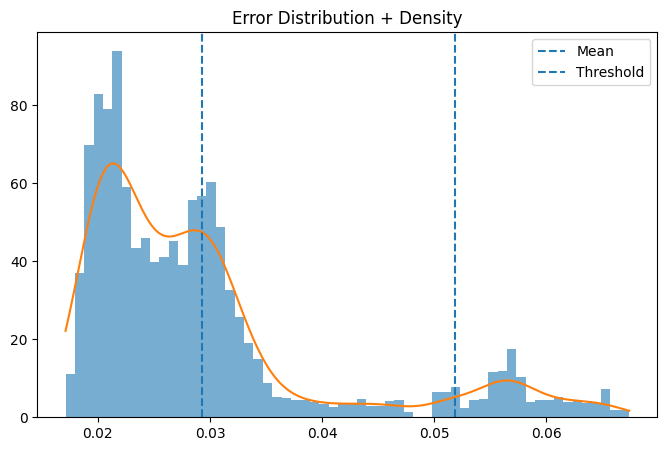

In [50]:
plt.figure(figsize=(8,5))

plt.hist(errors, bins=60, density=True, alpha=0.6)

# KDE approximation
from scipy.stats import gaussian_kde
kde = gaussian_kde(errors)
x_vals = np.linspace(errors.min(), errors.max(), 500)
plt.plot(x_vals, kde(x_vals))

plt.axvline(errors.mean(), linestyle='--', label='Mean')
plt.axvline(errors.mean() + 2*errors.std(), linestyle='--', label='Threshold')

plt.title("Error Distribution + Density")
plt.legend()
plt.show()